# Блок 3. Продвинутый уровень. Занятие 14

## Скорость изменения данных и приближённые производные

### Тема занятия

На предыдущих занятиях мы работали с реальными данными, искали зависимости, максимумы и минимумы.

Сначала изучите SOLVED-ноутбук вместе с преподавателем. Затем выполните TODO-ноутбук самостоятельно.

Сегодня изучаем более сложную идею:

```text
скорость изменения показателя
```

В математике это связано с производной.

В анализе данных мы часто не знаем настоящую формулу функции, но у нас есть таблица значений.  
Тогда можно считать **приближённую производную** через разности соседних значений.

---

## Датасет занятия: недвижимость

Используем открытый датасет California Housing.

Ссылка для загрузки:

```text
https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv
```

Датасет содержит информацию о районах Калифорнии и стоимости жилья.

### Описание колонок на русском языке

| Колонка | Описание |
|---|---|
| longitude | долгота района |
| latitude | широта района |
| housing_median_age | медианный возраст домов в районе |
| total_rooms | общее количество комнат в районе |
| total_bedrooms | общее количество спален в районе |
| population | население района |
| households | количество домохозяйств |
| median_income | медианный доход жителей района |
| median_house_value | медианная стоимость жилья |
| ocean_proximity | близость к океану |

---

## Прикладное значение

Такая задача полезна для:

- анализа рынка недвижимости;
- оценки влияния дохода на стоимость жилья;
- поиска резких изменений цены;
- предварительной подготовки к машинному обучению;
- понимания трендов и зависимостей.

---

## Математическая идея

Если у нас есть два соседних значения:

```text
x1, y1
x2, y2
```

то приближённая скорость изменения:

```text
delta_y / delta_x = (y2 - y1) / (x2 - x1)
```

Это похоже на производную.

---

## Связь с дипломом

В дипломном проекте такая логика пригодится для тем:

- недвижимость: как цена меняется при росте дохода;
- финансы: как меняется прибыль по годам;
- спорт: как меняется результат от нагрузки;
- питание: как меняются калории от БЖУ;
- HR: как score меняется от опыта.

---

## GitHub

```bash
git checkout main
git pull origin main
git checkout -b feature/math-advanced-lesson14-derivatives-real-estate

git add .
git commit -m "feat: add real estate derivative analysis lesson"
git push -u origin feature/math-advanced-lesson14-derivatives-real-estate
```

## Ячейка 1. TODO: импорт библиотек

### Алгоритм

1. Импортируйте `pandas`.
2. Импортируйте `numpy`.
3. Импортируйте `matplotlib.pyplot`.
4. Добавьте проверки.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Библиотеки подключены")

assert pd is not None
assert np is not None
assert plt is not None


Библиотеки подключены


## Ячейка 2. TODO: загрузка датасета недвижимости

### Алгоритм

1. Создайте переменную `url`.
2. Вставьте ссылку на датасет.
3. Загрузите CSV через `pd.read_csv`.
4. Покажите первые строки.

In [64]:
url = "../../data/Food_Nutrition_Dataset.csv"

df = pd.read_csv(url)

display(df.head())

assert len(df) > 0


,food_name,category,calories,protein,carbs,fat,iron,vitamin_c
0,"Apple, candied",Apples,134.0,1.34,29.61,2.15,0.12,3.6
1,"Apple, raw",Apples,61.0,0.17,14.80,0.15,0.03,4.6
2,"Apple, dried",Dried fruits,243.0,0.93,65.89,0.32,1.40,3.9
3,"Crisp, apple",Cakes and pies,215.0,2.81,30.18,9.59,1.00,0.6
4,"Apple, baked",Apples,113.0,0.32,22.70,3.08,0.19,3.9


## Ячейка 3. TODO: описание колонок на русском

### Алгоритм

1. Создайте словарь `column_description`.
2. Добавьте русское описание колонок.
3. Выведите размер таблицы.
4. Выведите описание колонок.

In [65]:
column_description = {"food_name": "название",
                      "category": "категория",
                      "calories": "калории",
                      "carbs": "углеводы",
                      "fat":"жиры",
                      "iron": "железо",
                      "vitamin_c": "витамин С"}

print("Размер таблицы:", df.shape)
print()

for column, description in column_description.items():
    print(column, "—", description)

assert "food_name" in df.columns
assert "calories" in df.columns


Размер таблицы: (205, 8)

food_name — название
category — категория
calories — калории
carbs — углеводы
fat — жиры
iron — железо
vitamin_c — витамин С


## Ячейка 4. TODO: статистика по доходу и цене

### Алгоритм

1. Выберите колонки `median_income` и `median_house_value`.
2. Используйте `describe()`.
3. Проверьте максимум и минимум.

In [66]:
selected_columns = ["fat", "calories"]

stats = df[selected_columns].describe()

display(stats)

assert stats.loc["max", "fat"] > stats.loc["min", "fat"]
assert stats.loc["max", "calories"] > stats.loc["min", "calories"]


,fat,calories
count,205.000000,205.000000
mean,6.018000,243.790244
std,9.694549,283.580451
min,0.000000,16.000000
25%,0.200000,62.000000
50%,1.180000,166.000000
75%,9.390000,296.000000
max,74.020000,1460.000000


## Ячейка 5. TODO: scatter plot

### Алгоритм

1. По X возьмите `median_income`.
2. По Y возьмите `median_house_value`.
3. Постройте scatter plot.
4. Добавьте подписи осей и сетку.

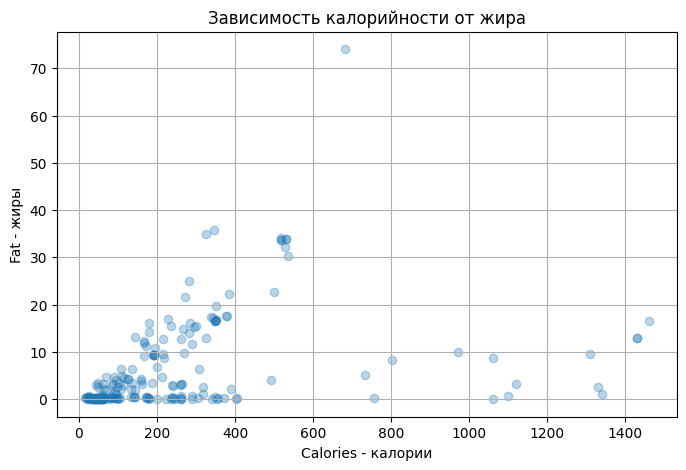

In [67]:
plt.figure(figsize=(8, 5))

plt.scatter(df["calories"], df["fat"], alpha=0.3)

plt.title("Зависимость калорийности от жира")
plt.ylabel("Fat - жиры")
plt.xlabel("Calories - калории")
plt.grid(True)

plt.show()

assert len(df["fat"]) == len(df["calories"])


## Ячейка 6. TODO: подготовка данных

### Алгоритм

1. Отсортируйте данные по `median_income`.
2. Возьмите первые 500 строк.
3. Сбросьте индекс.
4. Проверьте, что доход идёт по возрастанию.

In [68]:
sorted_df = df.sort_values("calories").reset_index(drop=True)

sample_df = sorted_df.head(500).copy()

display(sample_df[["calories", "fat"]].head())

assert sample_df["calories"].is_monotonic_increasing

,calories,fat
0,16.0,0.25
1,19.0,0.41
2,20.0,0.31
3,22.0,0.31
4,23.0,0.10


## Ячейка 7. TODO: приближённая производная

### Алгоритм

1. Посчитайте `delta_income`.
2. Посчитайте `delta_price`.
3. Посчитайте `approx_derivative`.
4. Уберите бесконечности и пропуски.

In [69]:
sample_df["delta_calories"] = sample_df["calories"].diff()
sample_df["delta_fat"] = sample_df["fat"].diff()

sample_df["approx_derivative"] = sample_df["delta_fat"] / sample_df["delta_calories"]

sample_df = sample_df.replace([np.inf, -np.inf], np.nan)
sample_df = sample_df.dropna(subset=["approx_derivative"])

display(
    sample_df.head()
)

assert "approx_derivative" in sample_df.columns
assert len(sample_df) > 0


,food_name,category,calories,protein,carbs,fat,iron,vitamin_c,delta_calories,delta_fat,approx_derivative
1,"Soup, tomato","Soups, broth-based",19.0,0.65,3.64,0.41,0.44,5.9,3.0,0.16,0.053333
2,"Tomatoes, raw",Tomatoes,20.0,0.82,4.04,0.31,0.22,16.3,1.0,-0.10,-0.100000
3,Tomato juice cocktail,Vegetable juice,22.0,0.93,3.87,0.31,0.28,54.3,2.0,0.00,0.000000
4,"Grape juice drink, light",Fruit drinks,23.0,0.06,5.51,0.10,0.03,17.6,1.0,-0.21,-0.210000
6,"Peppers, banana, raw",Other vegetables and combinations,27.0,1.66,5.35,0.45,0.46,82.7,4.0,0.31,0.077500


## Ячейка 8. TODO: графики цены и производной

### Алгоритм

1. Постройте график цены жилья от дохода.
2. Постройте график приближённой производной.
3. Добавьте подписи и сетку.

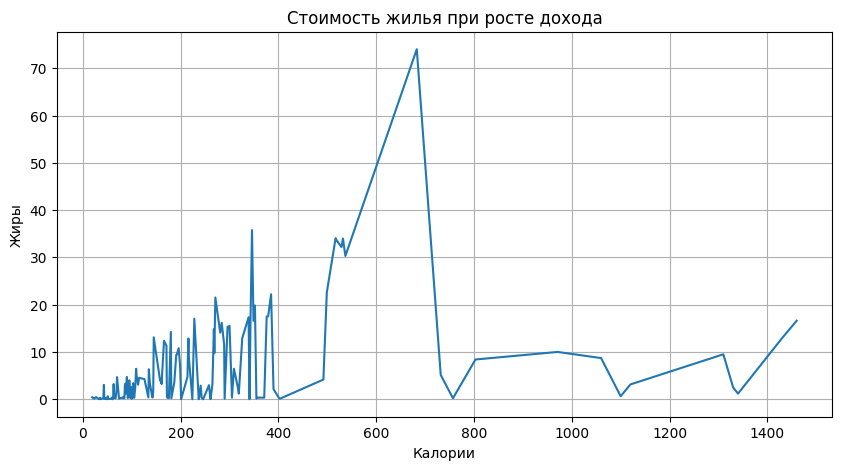

In [70]:
plt.figure(figsize=(10, 5))
plt.plot(sample_df["calories"], sample_df["fat"])

plt.title("Стоимость жилья при росте дохода")
plt.xlabel("Калории")
plt.ylabel("Жиры")
plt.grid(True)
plt.show()

## Ячейка 9. TODO: сглаживание производной

### Алгоритм

1. Создайте колонку `derivative_smooth`.
2. Используйте rolling(window=20).mean().
3. Постройте график.

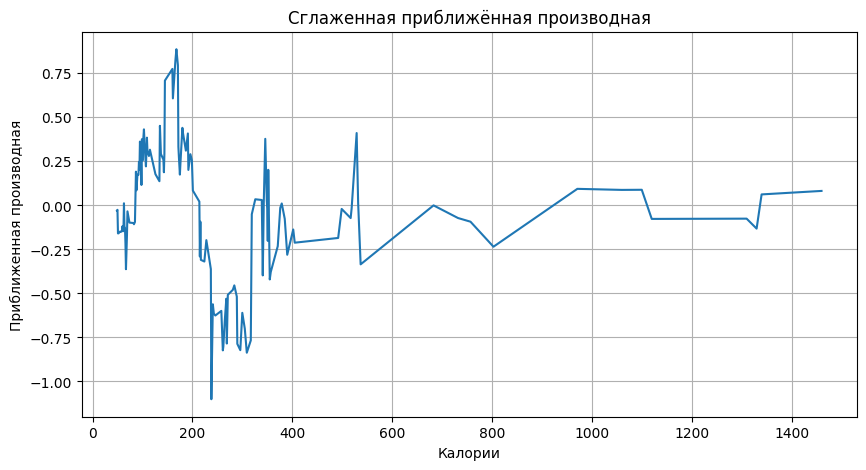

In [71]:
sample_df["derivative_smooth"] = (
    sample_df["approx_derivative"].rolling(window=20).mean()
)

plt.figure(figsize=(10, 5))
plt.plot(sample_df["calories"], sample_df["derivative_smooth"])

plt.title("Сглаженная приближённая производная")
plt.xlabel("Калории")
plt.ylabel("Приближенная производная")
plt.grid(True)
plt.show()

assert "derivative_smooth" in sample_df.columns

## Ячейка 10. TODO: итоговый отчёт

### Алгоритм

1. Создайте словарь `report`.
2. Добавьте количество строк, средний доход, среднюю цену и среднюю производную.
3. Создайте список из 5 выводов.
4. Выведите отчёт.

In [72]:
report = {
    "rows_count": len(df),
    "sample_rows": len(sample_df),
    "mean_income": df["calories"].mean(),
    "mean_house_value": df["fat"].mean(),
    "mean_approx_derivative": sample_df["approx_derivative"].mean(),
}

for key, value in report.items():
    print(key, ":", value)

conclusions = [
    "Калорийность можно рассматривать как функцию доли жиров",
    "Scatter plot показывает общую зависимость между калорийнностью и жирами в продукте.",
    "Приближённая производная показывает скорость калорийности.",
    "Реальные данные шумные, поэтому полезно сглаживание.",
    "Такой подход можно использовать в дипломе по аналитике дневника питания.",
]

print()
print("Выводы:")
for item in conclusions:
    print("-", item)

assert report["rows_count"] > 100
assert len(conclusions) == 5


rows_count : 205
sample_rows : 152
mean_income : 243.79024390243902
mean_house_value : 6.018000000000001
mean_approx_derivative : -0.033014074276724446

Выводы:
- Калорийность можно рассматривать как функцию доли жиров
- Scatter plot показывает общую зависимость между калорийнностью и жирами в продукте.
- Приближённая производная показывает скорость калорийности.
- Реальные данные шумные, поэтому полезно сглаживание.
- Такой подход можно использовать в дипломе по аналитике дневника питания.


# Итог TODO-задания

Покажите преподавателю:

- загрузку датасета недвижимости;
- русское описание колонок;
- scatter plot цены от дохода;
- расчёт приближённой производной;
- график производной;
- сглаживание;
- итоговый отчёт.